# Part 1: Dataset with coefficients

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'PROD'].reset_index(drop=True)

df = df[['N_w', 'N_o', 'coef_water', 'oil_prod']]


KeyError: "['N_w', 'N_o', 'coef_water'] not in index"

In [ ]:
df

,N_w,N_o,coef_water,oil_prod
0,2.188532,4.174369,0.00100,45165.0
1,2.188532,3.585042,0.00010,45248.7
2,2.188532,2.237464,0.00001,45472.9
3,2.188532,3.372366,0.00010,45294.5
4,2.188532,1.511511,0.00100,45614.0
...,...,...,...,...
2356,3.729212,3.132932,0.00100,45331.3
2357,3.729212,3.160948,0.00001,45330.7
2358,3.729212,1.601287,0.00001,45589.1
2359,3.729212,1.203706,0.00010,45663.7


In [ ]:
# df = df[(df['N_w'] >= 1) & (df['N_w'] <= 3.5) & (df['N_o'] >= 1) & (df['N_o'] <= 3.5)]

In [ ]:
df.describe()

,N_w,N_o,coef_water,oil_prod
count,2361.000000,2361.000000,2361.000000,2361.000000
mean,3.411698,2.885521,0.000355,45377.485472
std,0.971302,1.223893,0.000441,203.841530
min,0.997730,0.800497,0.000010,45016.300000
25%,2.631501,1.792473,0.000010,45201.100000
50%,3.729212,2.883813,0.000100,45379.000000
75%,4.271859,3.932217,0.001000,45559.800000
max,4.948806,4.999405,0.001000,45731.200000


### Simple linear regression and random forest

In [ ]:
X = df[['N_o', 'N_w', 'coef_water']]
y = df['oil_prod']

print('shape X - ', X.shape)
print('shape Y - ', y.shape)

# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


shape X -  (2361, 3)
shape Y -  (2361,)
X_train.shape:  (1888, 3)
X_train.shape:  (1888, 3)
X_test.shape (473, 3)
LinearRegression() part


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [1, 2, 3, 'sqrt', None],
    'bootstrap': [True, False],
}
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('best params:', search.best_params_)
# best params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'bootstrap': True}
# best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
print('best CV score:', -search.best_score_)

random_forest_model = search.best_estimator_


random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [-1.33489019e-01 -1.66406919e+02 -2.75126116e+02]
MAE:  6.007241208375952
MSE:  62.73862844898504
RMSE:  7.92077196042059
R^2:  0.998494453378932
RandomForestRegressor
Fitting 5 folds for each of 40 candidates, totalling 200 fits
best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
best CV score: 54.56195461941856
random forest results:
MAE:  5.91084120990794
MSE:  62.5140071868589
RMSE:  7.906579993072788
R^2:  0.9984998436431213


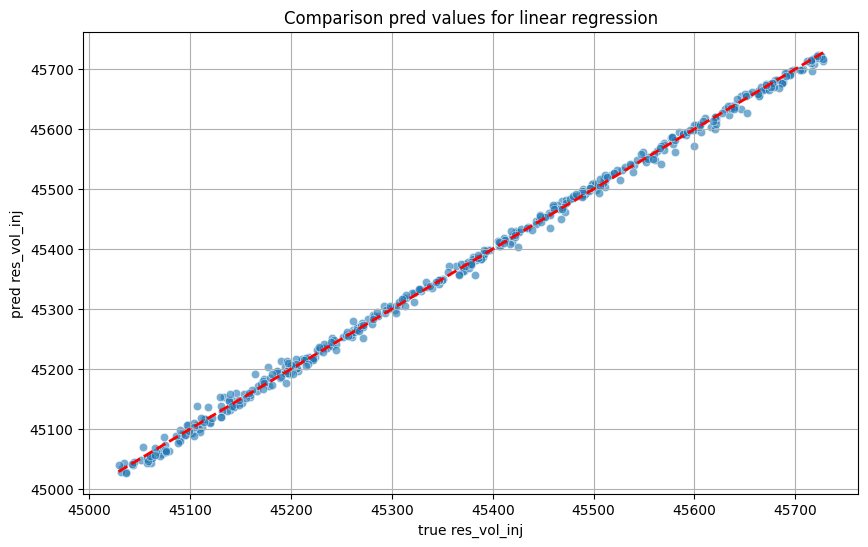

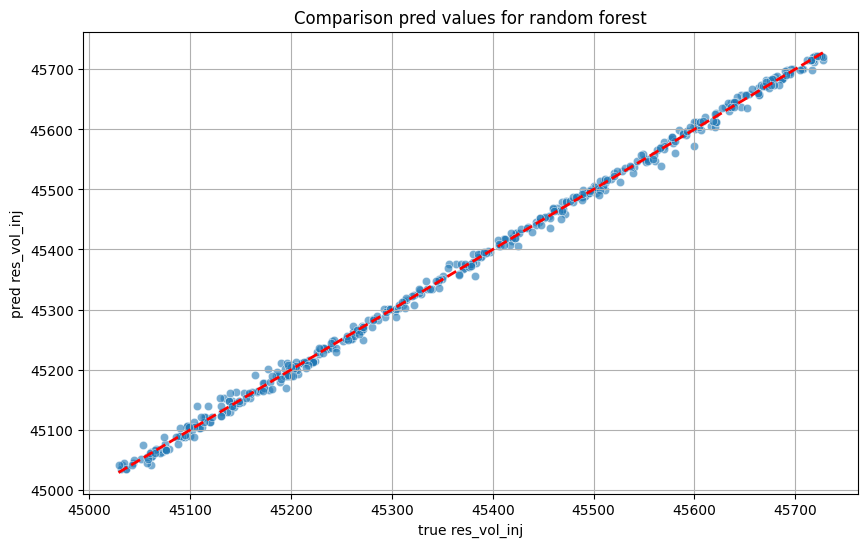

predict some values
new data: 
    N_w  N_o  coef_water
0  4.05    5      0.0001
1  8.00    3      0.0100
2  2.00    1      0.0010
predicted res_vol_inj:
[45035.09454704 45358.33174283 45695.00977021]
Features importance
N_o           0.999923
N_w           0.000057
coef_water    0.000020
dtype: float64


In [ ]:
# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

# visualizing part for random forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for random forest')
plt.grid(True)
plt.show()

print('predict some values')
new_data_for_prediction = pd.DataFrame({
    'N_w': [4.05, 8, 2],
    'N_o': [5, 3, 1],
    'coef_water': [0.0001, 0.01, 0.001]
})
predicted_res_vol_inj = random_forest_model.predict(new_data_for_prediction)

print(f'new data: \n{new_data_for_prediction}')
print(f'predicted res_vol_inj:\n{predicted_res_vol_inj}')

print('Features importance')
feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))


In [ ]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name)
    print('MAE:', mean_absolute_error(y_test, pred))
    print('MSE:', mean_squared_error(y_test, pred))
    print('RMSE:', np.sqrt(mean_squared_error(y_test, pred)))
    print('R2:', r2_score(y_test, pred))
    print()

Ridge
MAE: 5.998410998711689
MSE: 62.75321089723327
RMSE: 7.921692426321112
R2: 0.9984941034421191

Lasso
MAE: 5.999236297541905
MSE: 62.72034008894757
RMSE: 7.919617420617461
R2: 0.9984948922469682

ElasticNet
MAE: 5.998442559967696
MSE: 62.75117416450325
RMSE: 7.921563871137015
R2: 0.9984941523178461



so, the best model is Random Forest

#### Collect some statistic

In [ ]:
test_df = X_test

test_df['oil_prod_pred'] = y_pred_rf
test_df['oil_prod'] = y_test
test_df

,N_w,N_o,coef_water,oil_prod_pred,oil_prod
1138,2.386256,4.174602,0.00001,45162.804574,45165.8
2024,4.948806,3.534877,0.00010,45267.105831,45267.2
1605,4.271859,4.609854,0.00100,45087.977128,45094.9
1975,2.669601,2.922598,0.00010,45375.561821,45363.5
1701,4.888958,1.684713,0.00100,45579.242134,45570.0
...,...,...,...,...,...
1402,4.273574,3.079976,0.00010,45347.023057,45343.9
808,4.680246,2.687275,0.00100,45407.919360,45411.5
65,3.353715,3.451034,0.00100,45282.261119,45281.5
2248,1.888423,4.821032,0.00001,45061.654144,45064.5


                                                        value
count                                                     473
mean                                                 0.053607
variance                                            62.643572
std(sigma)                                           7.914769
median                                               0.035308
mode        [-27.794065583264455, -26.686682440325967, -26...


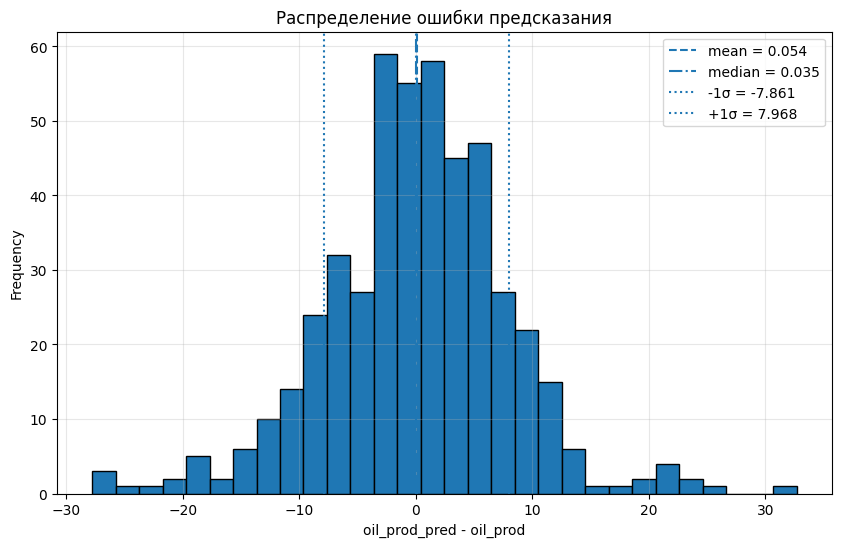

In [ ]:
test_df['diff'] = test_df['oil_prod_pred'] - test_df['oil_prod']

diff = test_df['diff']

stats = {
    'count': diff.count(),
    'mean': diff.mean(),
    'variance': diff.var(),
    'std(sigma)': diff.std(),
    'median': diff.median(),
    'mode': diff.mode().tolist()
}

stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['value'])
print(stats_df)

plt.figure(figsize=(10, 6))
plt.hist(diff, bins=30, edgecolor='black')
plt.axvline(diff.mean(), linestyle='--', label=f'mean = {diff.mean():.3f}')
plt.axvline(diff.median(), linestyle='-.', label=f'median = {diff.median():.3f}')
plt.axvline(diff.mean() - diff.std(), linestyle=':', label=f'-1σ = {diff.mean() - diff.std():.3f}')
plt.axvline(diff.mean() + diff.std(), linestyle=':', label=f'+1σ = {diff.mean() + diff.std():.3f}')
plt.xlabel('oil_prod_pred - oil_prod')
plt.ylabel('frequency')
plt.title('distribution of prediction error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Sobol coefficient

/tmp/ipykernel_5208/791211352.py:14: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


      feature        S1        ST   S1_conf       ST_conf
1         N_o  0.999847  0.999626  0.074146  5.865025e-02
0         N_w -0.000002  0.000007  0.000216  1.364568e-06
2  coef_water -0.000011  0.000001  0.000106  5.383285e-07


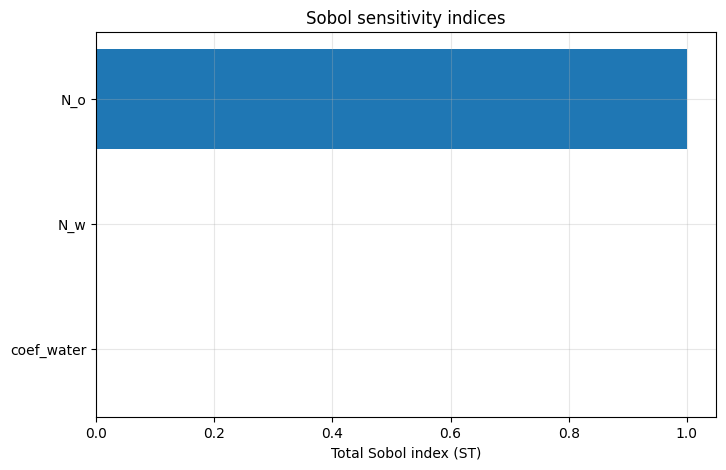

Pairwise interactions S2:
            N_w       N_o  coef_water
N_w         NaN -0.000168    0.000008
N_o         NaN       NaN   -0.000128
coef_water  NaN       NaN         NaN


In [ ]:
from SALib.sample import saltelli
from SALib.analyze import sobol

problem = {
    'num_vars': 3,
    'names': ['N_w', 'N_o', 'coef_water'],
    'bounds': [
        [df['N_w'].min(), df['N_w'].max()],
        [df['N_o'].min(), df['N_o'].max()],
        [df['coef_water'].min(), df['coef_water'].max()],
    ]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)

X_sobol = pd.DataFrame(param_values, columns=problem['names'])
Y = random_forest_model.predict(X_sobol)

Si = sobol.analyze(problem, Y, calc_second_order=True)

sobol_df = pd.DataFrame({
    'feature': problem['names'],
    'S1': Si['S1'],
    'ST': Si['ST'],
    'S1_conf': Si['S1_conf'],
    'ST_conf': Si['ST_conf'],
})

print(sobol_df.sort_values('ST', ascending=False))

sobol_df_sorted = sobol_df.sort_values('ST', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
plt.xlabel('Total Sobol index (ST)')
plt.title('Sobol sensitivity indices')
plt.grid(True, alpha=0.3)
plt.show()

print('Pairwise interactions S2:')
print(pd.DataFrame(Si['S2'], index=problem['names'], columns=problem['names']))

### Monte-Carlo method

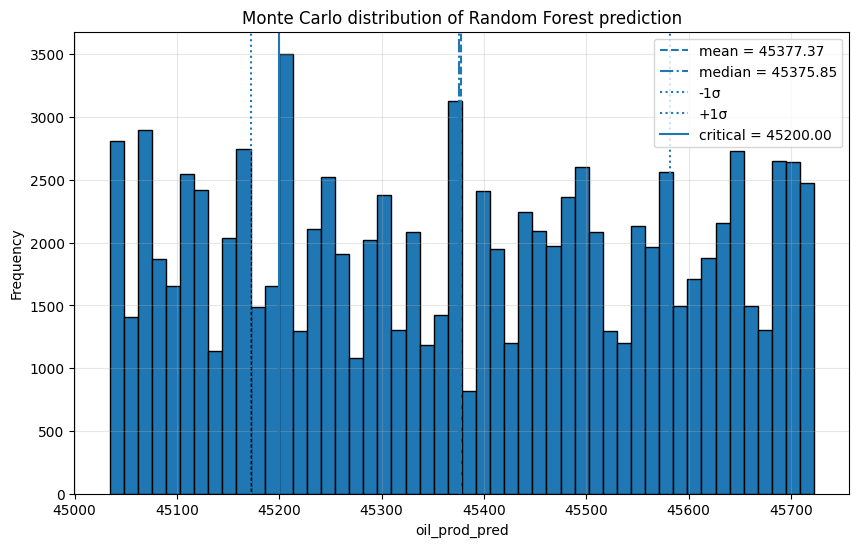

mean                      45377.366297
variance                  41824.236318
std                         204.509746
median                    45375.851382
mode_approx_bin_center             NaN
q01                       45040.366729
q05                       45066.769302
q25                       45200.226082
q75                       45559.293528
q95                       45695.696929
q99                       45720.177063
min                       45034.223592
max                       45722.702750
P(y < 45200)                  0.249040
Name: mc_stats, dtype: float64


In [ ]:
def mc_risk_analysis_rf(model, df, n_mc=100_000, critical_value=None, random_state=42):
    rng = np.random.default_rng(random_state)

    X_mc = pd.DataFrame({
        "N_w": rng.choice(df["N_w"].values, size=n_mc, replace=True),
        "N_o": rng.choice(df["N_o"].values, size=n_mc, replace=True),
        "coef_water": rng.choice(df["coef_water"].values, size=n_mc, replace=True),
    })

    y_mc = model.predict(X_mc)

    stats = {
        "mean": np.mean(y_mc),
        "variance": np.var(y_mc, ddof=1),
        "std": np.std(y_mc, ddof=1),
        "median": np.median(y_mc),
        "mode_approx_bin_center": None,
        "q01": np.quantile(y_mc, 0.01),
        "q05": np.quantile(y_mc, 0.05),
        "q25": np.quantile(y_mc, 0.25),
        "q75": np.quantile(y_mc, 0.75),
        "q95": np.quantile(y_mc, 0.95),
        "q99": np.quantile(y_mc, 0.99),
        "min": np.min(y_mc),
        "max": np.max(y_mc),
    }

    if critical_value is not None:
        stats[f"P(y < {critical_value})"] = np.mean(y_mc < critical_value)

    stats = pd.Series(stats, name="mc_stats")

    plt.figure(figsize=(10, 6))
    plt.hist(y_mc, bins=50, edgecolor="black")
    plt.axvline(np.mean(y_mc), linestyle="--", label=f"mean = {np.mean(y_mc):.2f}")
    plt.axvline(np.median(y_mc), linestyle="-.", label=f"median = {np.median(y_mc):.2f}")
    plt.axvline(np.mean(y_mc) - np.std(y_mc, ddof=1), linestyle=":", label="-1σ")
    plt.axvline(np.mean(y_mc) + np.std(y_mc, ddof=1), linestyle=":", label="+1σ")
    if critical_value is not None:
        plt.axvline(critical_value, linestyle="-", label=f"critical = {critical_value:.2f}")
    plt.xlabel("oil_prod_pred")
    plt.ylabel("Frequency")
    plt.title("Monte Carlo distribution of Random Forest prediction")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return X_mc, y_mc, stats

X_mc, y_mc, stats = mc_risk_analysis_rf(
    model=random_forest_model,
    df=df,
    n_mc=100_000,
    critical_value=45200,
    random_state=42
)

print(stats)

## PCE

In [ ]:
from pclearn import OrthogonalPolynomialsFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

import time

In [ ]:
X = df[['N_w', 'N_o', ]].values
y = df['oil_prod'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tol_eps = 1.0e-6  # tolerance
n_cv_folds = 5
alphas = np.logspace(-5, 1, 5)
l1_ratio = np.linspace(0.05, 0.95, 10)
n_max_iter = 500

fitting_method = ElasticNetCV(l1_ratio=l1_ratio, alphas=alphas,
                              max_iter=n_max_iter, tol=tol_eps, cv=n_cv_folds,
                              fit_intercept=False, selection='random')


poly_degree = 8
n_samples_train, n_features = X_train.shape
poly_type = ['legendre'] * n_features
dlist = []
reduction = False
truncated_dim = 20
single_iter_dim = 10
niter = 500
nrand = 50

orthopoly = OrthogonalPolynomialsFeatures(
    degree=poly_degree, dlist=dlist, poly_type=poly_type,
    reduction=reduction, basis_dim=truncated_dim,
    single_iter_dim=single_iter_dim, niter=niter, nrand=nrand,
    clf=fitting_method)


In [ ]:
regression_pipeline = Pipeline(steps=[
    ('orthopoly', orthopoly),
    ('fitting_method', fitting_method)])

t_start = time.time()
regression_pipeline.fit(X_train, y_train)
print('Linear problem (with PCE basis) has been solved in {:6f} seconds'.format(time.time() - t_start))

n_output_features: 45


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.878e+10, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.798e+10, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Linear problem (with PCE basis) has been solved in 0.491745 seconds


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.058e+10, tolerance: 3.111e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.662e+09, tolerance: 3.111e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Prediction over the test data in 0.506649 seconds
MSE test 21130.64857499359


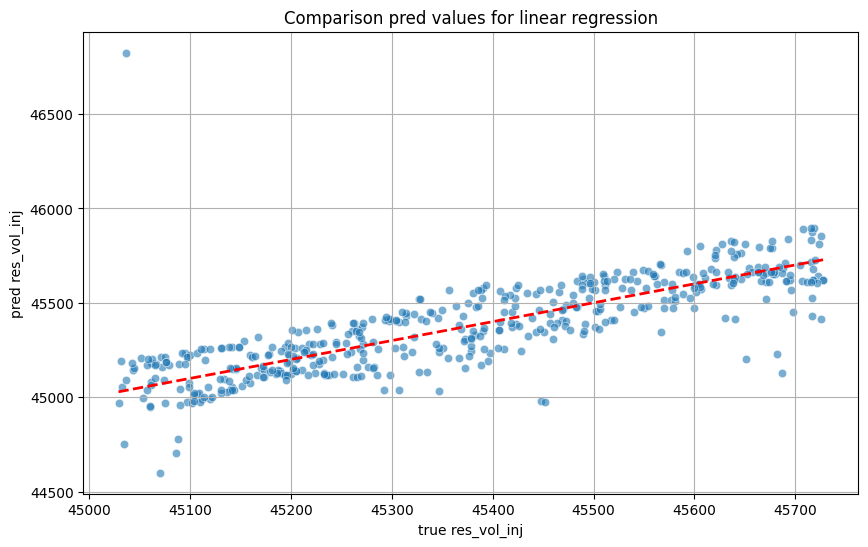

In [ ]:
y_test_pred = regression_pipeline.predict(X_test)
print('Prediction over the test data in {:6f} seconds'.format(time.time() - t_start))
mse_test = mean_squared_error(y_test, y_test_pred)
print('MSE test {}'.format(mse_test))

# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

## Risk Access (+ Sobol Coefficient + Monte-Carlo method above)

#### Creating big dataframe for future statistic

In [ ]:
import random as rd

In [ ]:
n = 10000
for_stat_df = pd.DataFrame({
    'N_w': [rd.uniform(0.8, 5) for _ in range(n)],
    'N_o': [rd.uniform(0.8, 5) for _ in range(n)],
    'coef_water': [rd.choice([10**-5, 10**-4, 10**-3]) for _ in range(n)]
})

In [ ]:
for_stat_df

,N_w,N_o,coef_water
0,4.377383,1.514562,0.00010
1,4.382326,1.054486,0.00100
2,3.644046,3.062819,0.00001
3,0.883793,4.506248,0.00010
4,4.024940,3.335655,0.00001
...,...,...,...
9995,1.624365,1.730846,0.00100
9996,3.199296,4.107013,0.00001
9997,3.042251,3.360678,0.00010
9998,3.259475,4.330554,0.00001


In [ ]:
pred_for_stat = random_forest_model.predict(for_stat_df)

for_stat_df['oil_prod_pred'] = pred_for_stat
for_stat_df

NameError: name 'pred_for_stat' is not defined

                       value
count                  10000
mean            45375.454824
variance         41335.98417
std               203.312528
median          45375.627597
mode      [45722.6564131324]
min             45034.223592
max              45722.70275
q25             45199.712232
q75             45551.020858


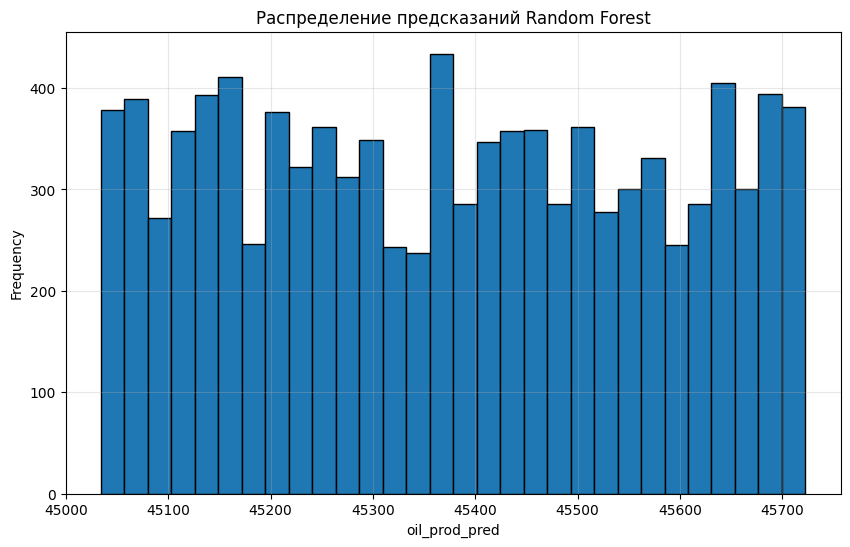

In [ ]:
pred_series = pd.Series(pred_for_stat, name='oil_prod_pred')

stats = {
    'count': pred_series.count(),
    'mean': pred_series.mean(),
    'variance': pred_series.var(),          # дисперсия
    'std': pred_series.std(),               # сигма = стандартное отклонение
    'median': pred_series.median(),
    'mode': pred_series.mode().tolist(),    # может быть несколько мод
    'min': pred_series.min(),
    'max': pred_series.max(),
    'q25': pred_series.quantile(0.25),
    'q75': pred_series.quantile(0.75),
}

stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['value'])
print(stats_df)

mean_val = pred_series.mean()
median_val = pred_series.median()
std_val = pred_series.std()

plt.figure(figsize=(10, 6))
plt.hist(pred_series, bins=30, edgecolor='black')
plt.xlabel('oil_prod_pred')
plt.ylabel('Frequency')
plt.title('distribution of Random Forest predictions')
plt.grid(True, alpha=0.3)
plt.show()

# Part 2: Dataset with whole SWOF matrix

In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'PROD'].reset_index(drop=True)

df = df[['iteration', 'water_relative_permeability', 'oil_relative_permeability', 'oil_prod']]

In [105]:
df

,iteration,water_relative_permeability,oil_relative_permeability,oil_prod
0,1,0.000001,0.659073,44196.0
1,1,0.000002,0.523490,44196.0
2,1,0.000003,0.408583,44196.0
3,1,0.000004,0.312461,44196.0
4,1,0.000005,0.233274,44196.0
...,...,...,...,...
27115,2497,0.000012,0.001790,43446.4
27116,2497,0.000014,0.000540,43446.4
27117,2497,0.000017,0.000111,43446.4
27118,2497,0.000020,0.000006,43446.4


In [106]:
X_rows = []
y_rows = []

for iteration_id, group in df.groupby("iteration"):
    group = group.sort_index()
    if len(group) != 15:
        continue
    
    features = []
    features.extend(group["water_relative_permeability"].tolist())
    features.extend(group["oil_relative_permeability"].tolist())
    X_rows.append(features)
    y_rows.append(group["oil_prod"].iloc[0])

X = pd.DataFrame(X_rows)
y = pd.Series(y_rows, name="oil_prod")


X.columns = (
    [f"water_rel_perm_{i+1}" for i in range(15)] +
    [f"oil_rel_perm_{i+1}" for i in range(15)])
X = X.drop(columns='oil_rel_perm_15') # this column always is 0
print(X.shape, y.shape)
df = X.join(y)

(1808, 29) (1808,)


In [107]:
pd.set_option('display.max_columns', None)
X

,water_rel_perm_1,water_rel_perm_2,water_rel_perm_3,water_rel_perm_4,water_rel_perm_5,water_rel_perm_6,water_rel_perm_7,water_rel_perm_8,water_rel_perm_9,water_rel_perm_10,water_rel_perm_11,water_rel_perm_12,water_rel_perm_13,water_rel_perm_14,water_rel_perm_15,oil_rel_perm_1,oil_rel_perm_2,oil_rel_perm_3,oil_rel_perm_4,oil_rel_perm_5,oil_rel_perm_6,oil_rel_perm_7,oil_rel_perm_8,oil_rel_perm_9,oil_rel_perm_10,oil_rel_perm_11,oil_rel_perm_12,oil_rel_perm_13,oil_rel_perm_14
0,0.000001,0.000002,0.000003,0.000004,0.000005,0.000006,0.000008,0.000009,0.000010,0.000011,0.000013,0.000014,0.000016,0.000018,0.000020,0.659073,0.523490,0.408583,0.312461,0.233274,0.169213,0.118512,0.079452,0.050366,0.029645,0.015738,0.007167,0.002537,0.000388
1,0.000001,0.000002,0.000002,0.000003,0.000004,0.000005,0.000006,0.000007,0.000008,0.000009,0.000010,0.000011,0.000013,0.000014,0.000016,0.856132,0.785733,0.716434,0.648303,0.581418,0.515870,0.451767,0.389238,0.328444,0.269586,0.212931,0.158845,0.107875,0.053616
2,0.000001,0.000002,0.000002,0.000003,0.000004,0.000005,0.000006,0.000007,0.000008,0.000009,0.000010,0.000011,0.000013,0.000014,0.000016,0.713375,0.591954,0.484282,0.389704,0.307546,0.237113,0.177687,0.128521,0.088839,0.057826,0.034621,0.018307,0.007892,0.001726
3,0.000001,0.000002,0.000003,0.000004,0.000005,0.000006,0.000008,0.000009,0.000010,0.000011,0.000013,0.000014,0.000016,0.000018,0.000020,0.758582,0.651199,0.552568,0.462582,0.381127,0.308080,0.243309,0.186668,0.137999,0.097122,0.063836,0.037904,0.019044,0.005491
4,0.000001,0.000002,0.000003,0.000004,0.000005,0.000006,0.000008,0.000009,0.000010,0.000011,0.000013,0.000014,0.000016,0.000018,0.000020,0.718016,0.597943,0.491071,0.396818,0.314587,0.243755,0.183679,0.133684,0.093066,0.061079,0.036930,0.019768,0.008661,0.001950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1803,0.000001,0.000003,0.000006,0.000011,0.000016,0.000023,0.000030,0.000040,0.000050,0.000062,0.000076,0.000091,0.000107,0.000128,0.000158,0.900040,0.849171,0.797641,0.745390,0.692342,0.638409,0.583483,0.527426,0.470062,0.411156,0.350379,0.287245,0.220958,0.137546
1804,0.000000,0.000000,0.000001,0.000001,0.000001,0.000002,0.000002,0.000003,0.000004,0.000005,0.000006,0.000007,0.000009,0.000010,0.000013,0.590841,0.441801,0.323136,0.230339,0.159282,0.106214,0.067759,0.040906,0.023011,0.011787,0.005300,0.001964,0.000530,0.000050
1805,0.000000,0.000000,0.000001,0.000001,0.000002,0.000003,0.000004,0.000005,0.000006,0.000008,0.000010,0.000011,0.000013,0.000016,0.000020,0.749662,0.639350,0.538713,0.447564,0.365709,0.292936,0.229023,0.173726,0.126781,0.087895,0.056743,0.032949,0.016073,0.004394
1806,0.000000,0.000000,0.000001,0.000001,0.000002,0.000002,0.000003,0.000004,0.000005,0.000006,0.000008,0.000009,0.000011,0.000013,0.000016,0.555275,0.401208,0.282815,0.193704,0.128244,0.081525,0.049322,0.028055,0.014746,0.006980,0.002856,0.000941,0.000217,0.000015


In [108]:
# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

X_train.shape:  (1446, 29)
X_train.shape:  (1446, 29)
X_test.shape (362, 29)
LinearRegression() part


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [109]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)


linear reg results:
linear model coeffs:  [-1.77934465e+05 -3.88528691e+05  1.58602561e+06 -1.30574332e+06
  1.65329184e+06 -2.84775331e+06  2.81845259e+06 -1.27248231e+06
 -8.05843140e+05  7.84021151e+05 -6.29964057e+05 -9.22767856e+05
  2.73292933e+06 -1.36831894e+06  6.63606841e+04 -7.34489890e+10
  2.42190777e+11 -2.77849509e+11 -1.65225023e+10  2.64517014e+11
 -3.88368169e+10 -2.72152105e+11  1.14922225e+11  2.66074710e+11
 -3.70129599e+11  2.13581917e+11 -6.42472216e+10  9.32086724e+09
 -3.67767584e+08]
MAE:  14.506787025599017
MSE:  541.3798405220775
RMSE:  23.267570576277997
R^2:  0.9982679425551779


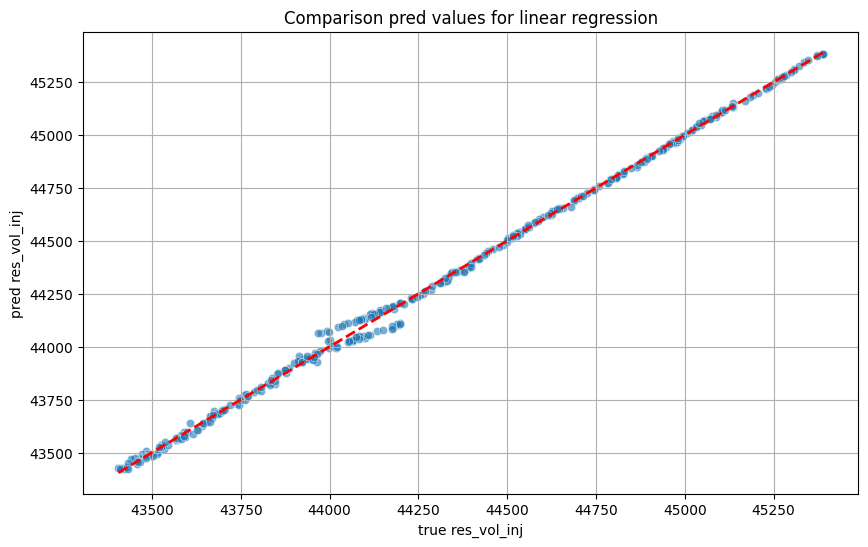

In [110]:
# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('true res_vol_inj')
plt.ylabel('pred res_vol_inj')
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

/tmp/ipykernel_5208/2092474565.py:41: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


              feature            S1            ST       S1_conf       ST_conf
19     oil_rel_perm_5  1.803520e-01  1.804506e-01  3.446374e-02  1.652125e-02
24    oil_rel_perm_10  1.775584e-01  1.774922e-01  3.613989e-02  1.674504e-02
17     oil_rel_perm_3  1.752374e-01  1.732035e-01  3.366670e-02  1.484592e-02
21     oil_rel_perm_7  1.694509e-01  1.694497e-01  3.175179e-02  1.455715e-02
23     oil_rel_perm_9  1.138283e-01  1.164129e-01  2.681732e-02  9.938231e-03
16     oil_rel_perm_2  1.012882e-01  1.014990e-01  2.242635e-02  9.848034e-03
25    oil_rel_perm_11  4.363286e-02  4.383360e-02  1.758458e-02  4.561623e-03
22     oil_rel_perm_8  2.349303e-02  2.622386e-02  1.473827e-02  2.354361e-03
15     oil_rel_perm_1  5.715133e-03  5.640741e-03  6.956573e-03  5.437987e-04
20     oil_rel_perm_6  3.719324e-03  3.787984e-03  4.885468e-03  3.372954e-04
26    oil_rel_perm_12  2.738648e-03  2.713211e-03  4.500537e-03  2.743906e-04
18     oil_rel_perm_4  6.880390e-04  6.915805e-04  2.248298e-03 

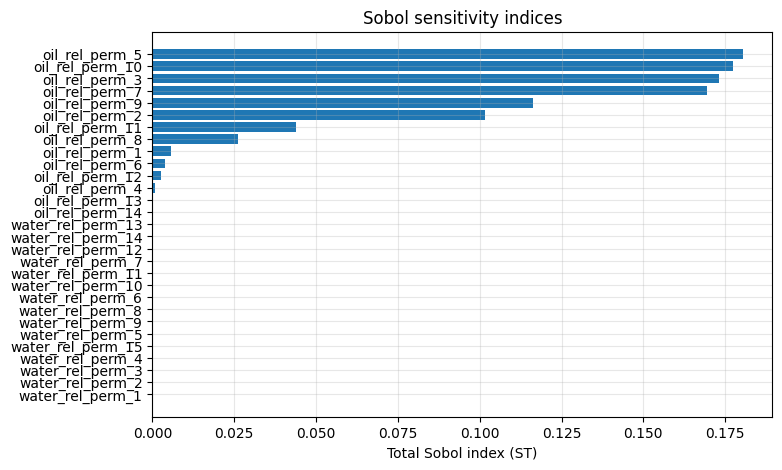

Pairwise interactions S2:
                   water_rel_perm_1  water_rel_perm_2  water_rel_perm_3  \
water_rel_perm_1                NaN      8.765298e-16      8.771526e-16   
water_rel_perm_2                NaN               NaN      1.114217e-15   
water_rel_perm_3                NaN               NaN               NaN   
water_rel_perm_4                NaN               NaN               NaN   
water_rel_perm_5                NaN               NaN               NaN   
water_rel_perm_6                NaN               NaN               NaN   
water_rel_perm_7                NaN               NaN               NaN   
water_rel_perm_8                NaN               NaN               NaN   
water_rel_perm_9                NaN               NaN               NaN   
water_rel_perm_10               NaN               NaN               NaN   
water_rel_perm_11               NaN               NaN               NaN   
water_rel_perm_12               NaN               NaN               NaN   

In [111]:
from SALib.sample import saltelli
from SALib.analyze import sobol
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = [
    'water_rel_perm_1','water_rel_perm_2','water_rel_perm_3','water_rel_perm_4','water_rel_perm_5',
    'water_rel_perm_6','water_rel_perm_7','water_rel_perm_8','water_rel_perm_9','water_rel_perm_10',
    'water_rel_perm_11','water_rel_perm_12','water_rel_perm_13','water_rel_perm_14','water_rel_perm_15',
    'oil_rel_perm_1','oil_rel_perm_2','oil_rel_perm_3','oil_rel_perm_4','oil_rel_perm_5',
    'oil_rel_perm_6','oil_rel_perm_7','oil_rel_perm_8','oil_rel_perm_9','oil_rel_perm_10',
    'oil_rel_perm_11','oil_rel_perm_12','oil_rel_perm_13','oil_rel_perm_14',
]

bounds = []
valid_features = []

for col in features:
    s = pd.to_numeric(df[col], errors='coerce')
    mn = s.min()
    mx = s.max()

    if pd.isna(mn) or pd.isna(mx):
        print(f"Пропущен {col}: NaN в границах")
        continue

    if mn == mx:
        print(f"Пропущен {col}: min == max == {mn}")
        continue

    bounds.append([mn, mx])
    valid_features.append(col)

problem = {
    'num_vars': len(valid_features),
    'names': valid_features,
    'bounds': bounds
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)

X_sobol = pd.DataFrame(param_values, columns=problem['names'])
Y = linear_model.predict(X_sobol)

Si = sobol.analyze(problem, Y, calc_second_order=True)

sobol_df = pd.DataFrame({
    'feature': problem['names'],
    'S1': Si['S1'],
    'ST': Si['ST'],
    'S1_conf': Si['S1_conf'],
    'ST_conf': Si['ST_conf'],
})

print(sobol_df.sort_values('ST', ascending=False))

sobol_df_sorted = sobol_df.sort_values('ST', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
plt.xlabel('Total Sobol index (ST)')
plt.title('Sobol sensitivity indices')
plt.grid(True, alpha=0.3)
plt.show()

print('Pairwise interactions S2:')
print(pd.DataFrame(Si['S2'], index=problem['names'], columns=problem['names']))